<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/labexam_2_fianl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/agriculture_dataset.csv")

# Check basic info
print("Before Conversion:")
print(df.head())
print(df["Yield(tons)"].describe())

# Step 1: Calculate median yield value
median_yield = df["Yield(tons)"].median()
print("\nMedian Yield:", median_yield)

# Step 2: Create classification label
df["Yield_Class"] = (df["Yield(tons)"] > median_yield).astype(int)

# Step 3: Optional - Rename class labels for clarity
df["Yield_Class"] = df["Yield_Class"].replace({0:"Low", 1:"High"})

# Step 4: Drop original yield (optional, keep only class)
# df = df.drop("Yield(tons)", axis=1)

print("\nAfter Conversion (Classification Dataset):")
print(df.head())

# Save new dataset
df.to_csv("/content/agriculture_dataset_classification.csv", index=False)
print("\n✅ Classification dataset saved as agriculture_dataset_classification.csv")

Before Conversion:
  Farm_ID  Crop_Type  Farm_Area(acres) Irrigation_Type  Fertilizer_Used(tons)  \
0    F001     Cotton            329.40       Sprinkler                   8.14   
1    F002     Carrot             18.67          Manual                   4.77   
2    F003  Sugarcane            306.03           Flood                   2.91   
3    F004     Tomato            380.21        Rain-fed                   3.32   
4    F005     Tomato            135.56       Sprinkler                   8.33   

   Pesticide_Used(kg)  Yield(tons) Soil_Type  Season  \
0                2.21        14.44     Loamy  Kharif   
1                4.36        42.91     Peaty  Kharif   
2                0.56        33.44     Silty  Kharif   
3                4.35        34.08     Silty    Zaid   
4                4.48        43.28      Clay    Zaid   

   Water_Usage(cubic meters)  
0                   76648.20  
1                   68725.54  
2                   75538.56  
3                   45401.23  
4 

In [15]:
# ================= IMPORT LIBRARIES =================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# ================= LOAD DATA =================
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

print("Dataset Loaded Successfully ✅")
print(df.head())

# ================ IDENTIFY TARGET ================
target = "Yield_Class"

X = df.drop(columns=["Farm_ID", "Yield(tons)", target]) # Drop Farm_ID, original yield, and the target
y = df[target]

# ================= DATA PROCESSING =================
# Convert categorical features to numerical (One Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Convert target to numerical if it's not already (e.g., 'Low', 'High' to 0, 1)
y = y.map({'Low': 0, 'High': 1})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= TRAIN / TEST SPLIT ==============
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# ================= MODEL LIST =====================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)
}

# ================= TRAIN + EVALUATE =================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probability score for ROC-AUC
    try:
        y_proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = np.nan

    cm = confusion_matrix(y_test, y_pred)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        auc,
        cm
    ])

# ================= RESULTS TABLE =================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Confusion Matrix"
])

print("\n==================== MODEL PERFORMANCE SUMMARY ====================")
print(results_df)

Dataset Loaded Successfully ✅
  Farm_ID  Crop_Type  Farm_Area(acres) Irrigation_Type  Fertilizer_Used(tons)  \
0    F001     Cotton            329.40       Sprinkler                   8.14   
1    F002     Carrot             18.67          Manual                   4.77   
2    F003  Sugarcane            306.03           Flood                   2.91   
3    F004     Tomato            380.21        Rain-fed                   3.32   
4    F005     Tomato            135.56       Sprinkler                   8.33   

   Pesticide_Used(kg)  Yield(tons) Soil_Type  Season  \
0                2.21        14.44     Loamy  Kharif   
1                4.36        42.91     Peaty  Kharif   
2                0.56        33.44     Silty  Kharif   
3                4.35        34.08     Silty    Zaid   
4                4.48        43.28      Clay    Zaid   

   Water_Usage(cubic meters) Yield_Class  
0                   76648.20         Low  
1                   68725.54        High  
2                

Missing values before: Farm_ID                      0
Crop_Type                    0
Farm_Area(acres)             0
Irrigation_Type              0
Fertilizer_Used(tons)        0
Pesticide_Used(kg)           0
Yield(tons)                  0
Soil_Type                    0
Season                       0
Water_Usage(cubic meters)    0
Yield_Class                  0
dtype: int64
Missing values after: Farm_ID                      0
Crop_Type                    0
Farm_Area(acres)             0
Irrigation_Type              0
Fertilizer_Used(tons)        0
Pesticide_Used(kg)           0
Yield(tons)                  0
Soil_Type                    0
Season                       0
Water_Usage(cubic meters)    0
Yield_Class                  0
dtype: int64
Before SMOTE: Yield_Class
0    25
1    25
Name: count, dtype: int64
After SMOTE: Yield_Class
0    25
1    25
Name: count, dtype: int64


/tmp/ipython-input-2615271225.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-2615271225.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

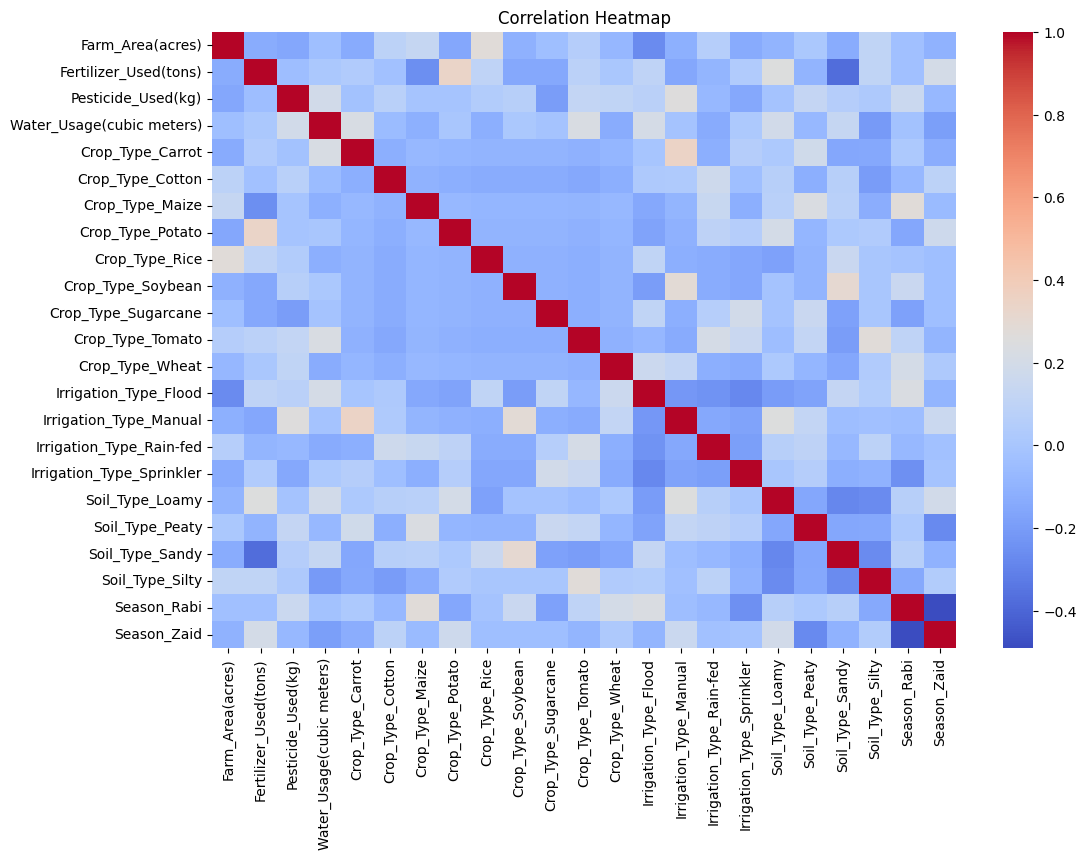

In [19]:
# STEP 1: PREPROCESSING

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

# ---------------- NULL VALUE HANDLING ----------------
# Check nulls
print("Missing values before:", df.isnull().sum())

# Fill missing numeric values with mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after:", df.isnull().sum())

# ---------------- SPLIT FEATURES & TARGET ----------------
# Drop Farm_ID and the target variable from features
X = df.drop(['Farm_ID', 'Yield_Class', 'Yield(tons)'], axis=1) # Also drop original yield
y = df['Yield_Class']

# ---------------- CONVERT CATEGORICAL → NUMERIC ----------------
# Select only object/category columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


# Convert target to numerical if it's not already (e.g., 'Low', 'High' to 0, 1)
y = y.map({'Low': 0, 'High': 1})

# ---------------- FEATURE SCALING (STANDARDIZATION) ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# ---------------- IMBALANCE HANDLING (SMOTE) ----------------
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", y_res.value_counts())

# ---------------- CORRELATION ANALYSIS ----------------
# Create DataFrame with scaled and resampled data and original column names for correlation
corr = pd.DataFrame(X_res, columns=X_encoded.columns).corr()
plt.figure(figsize=(12, 8)) # Increased figure size
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

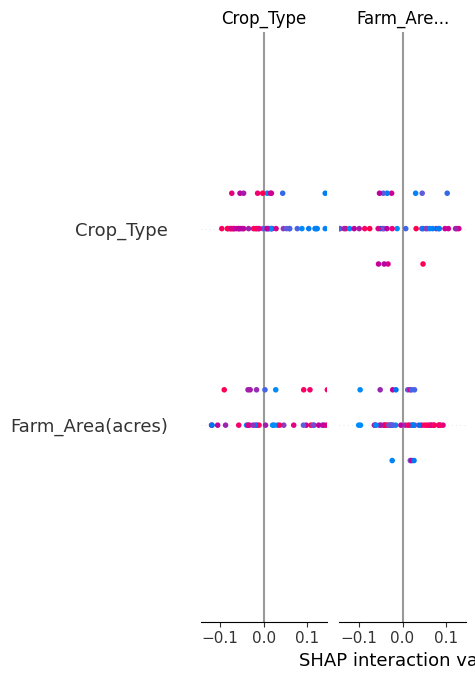

In [22]:
# STEP 2: SHAP FEATURE IMPORTANCE (Random Forest)

import shap
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on SMOTE balanced data
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_res, y_res)

# Initialize SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_res)

# Plot SHAP summary plot (global importance)
shap.summary_plot(shap_values, X_res, feature_names=X.columns)


In [23]:
# Get mean absolute SHAP values for feature ranking
shap_importance = np.mean(np.abs(shap_values), axis=1)
shap_ranking = pd.DataFrame(list(zip(X.columns, shap_importance[0])),
                            columns=['Feature','SHAP Importance'])
shap_ranking = shap_ranking.sort_values(by='SHAP Importance', ascending=False)
print(shap_ranking.head(15))


            Feature  SHAP Importance
1  Farm_Area(acres)         0.017583
0         Crop_Type         0.017583


In [24]:
# Select top k features (you can adjust k)
k = 10
important_features = shap_ranking.head(k)['Feature'].tolist()

X_final = X_res[:, [list(X.columns).index(feat) for feat in important_features]]

print("Selected Features:", important_features)


Selected Features: ['Farm_Area(acres)', 'Crop_Type']


,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters),Yield_Class
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20,Low
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54,High
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56,High
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23,High
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69,High


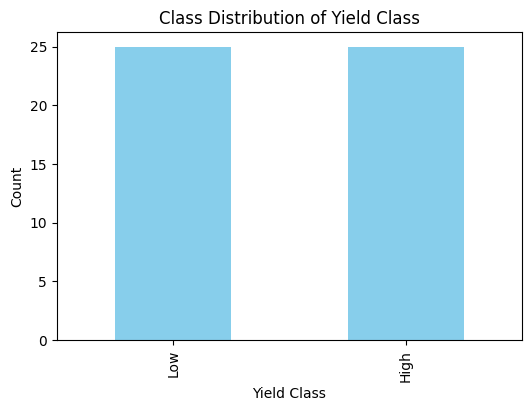

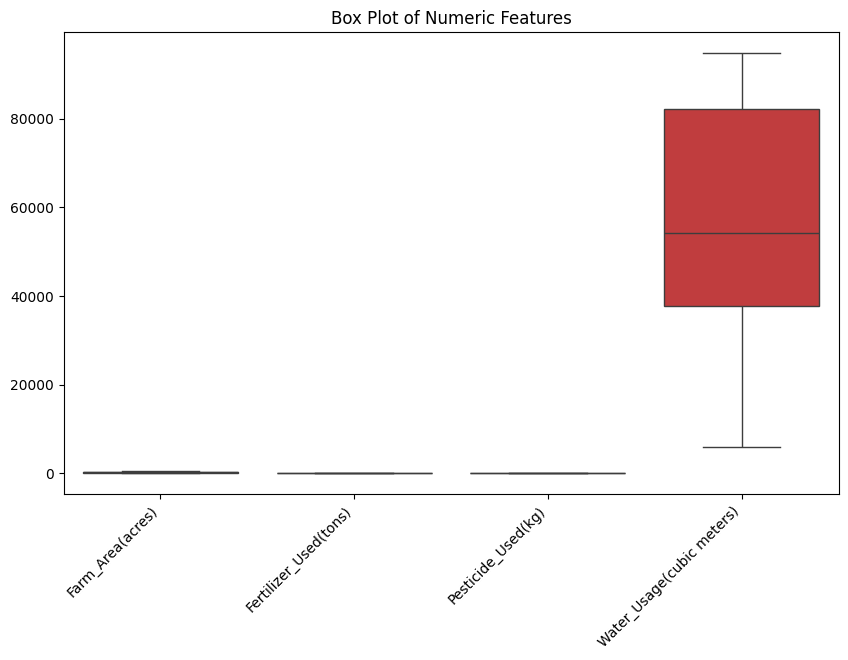

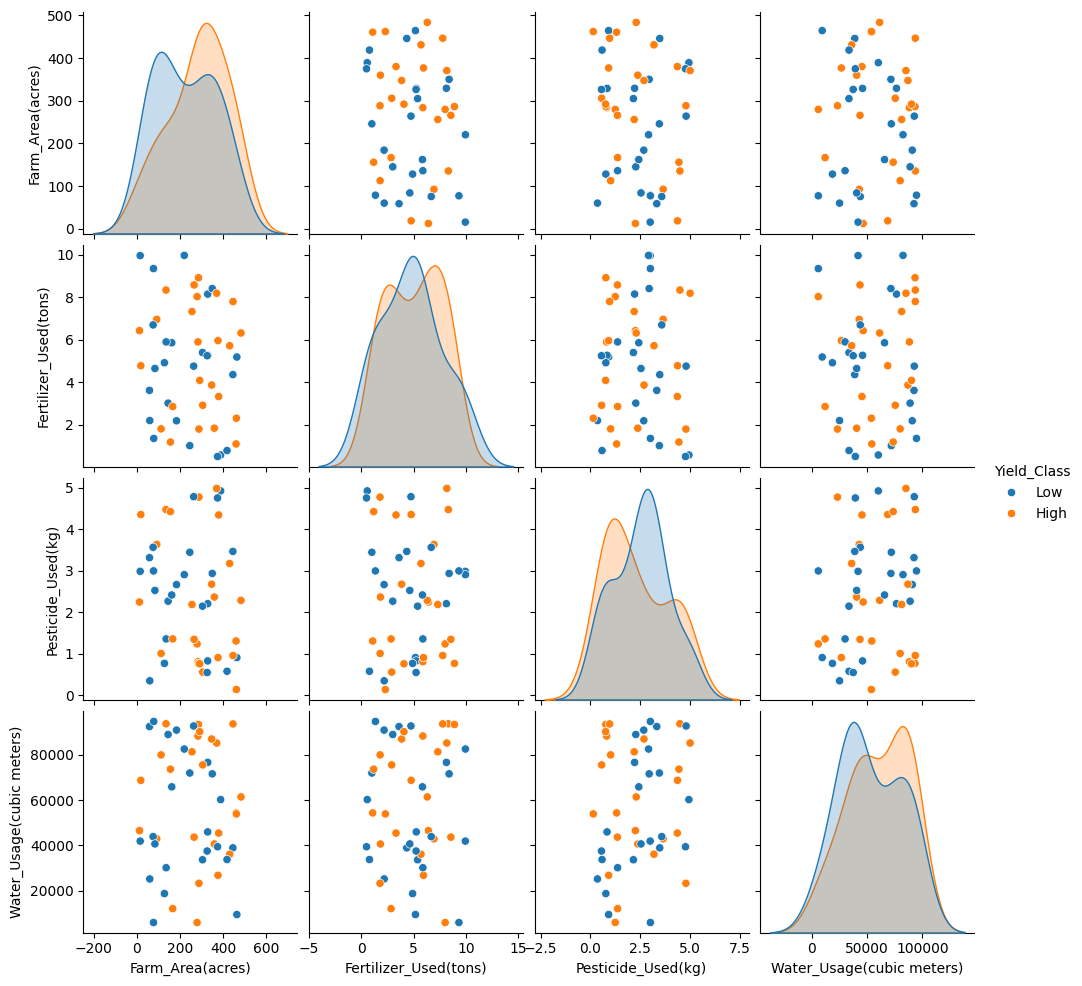

In [28]:
# STEP 3: Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

# Show first rows
display(df.head())

# ------------------ 1. BAR CHART (Class Distribution) ------------------
plt.figure(figsize=(6,4))
df['Yield_Class'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Class Distribution of Yield Class')
plt.xlabel('Yield Class')
plt.ylabel('Count')
plt.show()

# ------------------ 2. BOX PLOT (Identify Outliers for Numeric Features) ------------------
# Select relevant numeric columns from the dataframe
numeric_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Water_Usage(cubic meters)']
plt.figure(figsize=(10,6)) # Adjusted figure size for more features
sns.boxplot(data=df[numeric_cols])
plt.title('Box Plot of Numeric Features')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.show()

# ------------------ 3. PAIR PLOT (Multivariate Relationships) ------------------
# Select a subset of relevant features for pair plot
pairplot_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Water_Usage(cubic meters)', 'Yield_Class']
sns.pairplot(df[pairplot_cols], hue='Yield_Class')
plt.show()


===== Logistic Regression =====
Accuracy:  0.5385
Precision: 0.5278
Recall:    0.5238
F1-Score:  0.5125
AUC Score: 0.5238

===== Decision Tree =====
Accuracy:  0.5385
Precision: 0.5357
Recall:    0.5357
F1-Score:  0.5357
AUC Score: 0.5357

===== KNN =====
Accuracy:  0.4615
Precision: 0.4500
Recall:    0.4524
F1-Score:  0.4485
AUC Score: 0.4762

===== Naive Bayes =====
Accuracy:  0.3846
Precision: 0.2273
Recall:    0.3571
F1-Score:  0.2778
AUC Score: 0.2381

===== SVM =====
Accuracy:  0.3077
Precision: 0.3095
Recall:    0.3095
F1-Score:  0.3077
AUC Score: 0.6190


Model Performance Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0  Logistic Regression  0.538462   0.527778  0.523810  0.512500   0.523810
1        Decision Tree  0.538462   0.535714  0.535714  0.535714   0.535714
2                  KNN  0.461538   0.450000  0.452381  0.448485   0.476190
3          Naive Bayes  0.384615   0.227273  0.357143  0.277778   0.238095
4                  SVM 

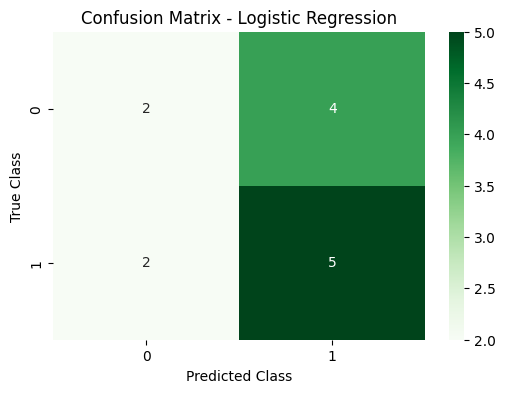

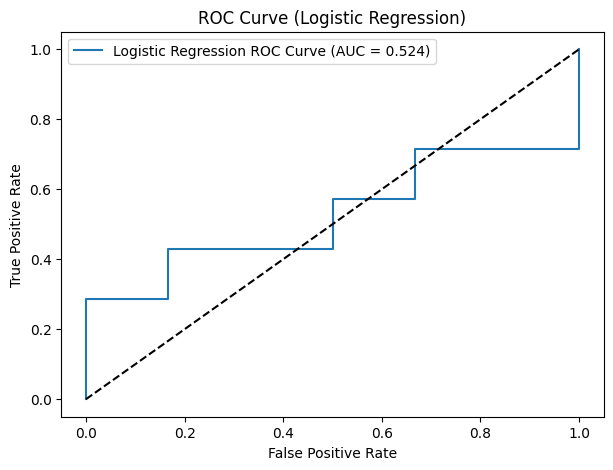

In [39]:
# STEP: Machine Learning Classification Models with Evaluation Metrics

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

import seaborn as sns
import matplotlib.pyplot as plt

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Load Dataset
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

# Encode Target Column
# Check if 'Yield_Class' is of object type before encoding
if df['Yield_Class'].dtype == 'object':
    le = LabelEncoder()
    df['Yield_Class'] = le.fit_transform(df['Yield_Class'])

# Separate Features and Target
X = df.drop(['Farm_ID', 'Yield(tons)', 'Yield_Class'], axis=1) # Drop Farm_ID, original yield, and the target
y = df['Yield_Class']

# Convert categorical features to numerical (One Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    # AUC Score (Multi-class) - Note: This is for binary classification, adjust for multi-class if needed
    # Since this is binary, we can use the probability of the positive class
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        # For multi-class, use one-vs-rest or one-vs-one approach for AUC
        # This dataset is binary, so the above will work.
        auc = "N/A for multi-class in this simplified example"


    results.append([name, accuracy, precision, recall, f1, auc])

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC Score: {auc:.4f}" if isinstance(auc, (int, float)) else f"AUC Score: {auc}")

# Convert Results to Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC Score"])
print("\n\nModel Performance Comparison:\n")
print(results_df)

# Plot Confusion Matrix for the Best Model (based on Accuracy)
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# ROC Curve (Binary Classification)
if len(np.unique(y_test)) == 2:
    y_score = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'{best_model_name} ROC Curve (AUC = {roc_auc_score(y_test, y_score):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({best_model_name})')
    plt.legend()
    plt.show()
else:
     print("⚠️ ROC Curve skipped (not binary classification).")


===== Bagging =====
Accuracy: 0.6154
Precision:0.6190
Recall:   0.6190
F1 Score: 0.6154

===== Random Forest =====
Accuracy: 0.3077
Precision:0.2875
Recall:   0.2976
F1 Score: 0.2909

===== Extra Trees =====
Accuracy: 0.3077
Precision:0.3095
Recall:   0.3095
F1 Score: 0.3077

===== AdaBoost =====
Accuracy: 0.5385
Precision:0.5278
Recall:   0.5238
F1 Score: 0.5125

===== Gradient Boosting =====
Accuracy: 0.6154
Precision:0.6125
Recall:   0.6071
F1 Score: 0.6061

===== Voting Classifier =====
Accuracy: 0.3846
Precision:0.3472
Recall:   0.3690
F1 Score: 0.3500

===== Stacking Classifier =====
Accuracy: 0.2308
Precision:0.2262
Recall:   0.2262
F1 Score: 0.2262


Final Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0              Bagging  0.615385   0.619048  0.619048  0.615385
1        Random Forest  0.307692   0.287500  0.297619  0.290909
2          Extra Trees  0.307692   0.309524  0.309524  0.307692
3             AdaBoost  0.538462   0.527778  0.523810  0.

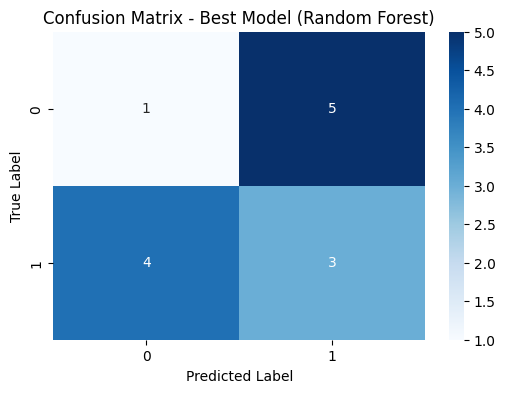

In [34]:
# STEP 6: Ensemble Machine Learning Models

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load dataset
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

# Encode target column
le = LabelEncoder()
df['Yield_Class'] = le.fit_transform(df['Yield_Class'])

X = df.drop(['Farm_ID', 'Yield(tons)', 'Yield_Class'], axis=1)
y = df['Yield_Class']

# Convert categorical features to numerical (One Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define models
models = {
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100)),
        ('et', ExtraTreesClassifier(n_estimators=100)),
        ('ada', AdaBoostClassifier(n_estimators=50))
    ],
    voting='soft'
)

models["Voting Classifier"] = voting_model

# Stacking Classifier
stack_model = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf', RandomForestClassifier(n_estimators=100))
    ],
    final_estimator=LogisticRegression()
)

models["Stacking Classifier"] = stack_model


# Train, Predict and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision:{precision:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# Convert Results to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\n\nFinal Comparison:\n")
print(results_df)

# Confusion Matrix for Best Model (Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Best Model (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4828 - loss: 0.9567 - val_accuracy: 0.3750 - val_loss: 0.7058
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5517 - loss: 0.8738 - val_accuracy: 0.3750 - val_loss: 0.7056
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4828 - loss: 0.7742 - val_accuracy: 0.2500 - val_loss: 0.7069
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5172 - loss: 0.8274 - val_accuracy: 0.2500 - val_loss: 0.7083
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4483 - loss: 0.7530 - val_accuracy: 0.2500 - val_loss: 0.7099
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6207 - loss: 0.6925 - val_accuracy: 0.3750 - val_loss: 0.7114
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6207 - loss: 0.6598 - val_accuracy: 0.3750 - val_loss: 0.7130
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5862 - loss: 0.7285 - val_accuracy: 0.3750 - val_loss: 0.7148
E

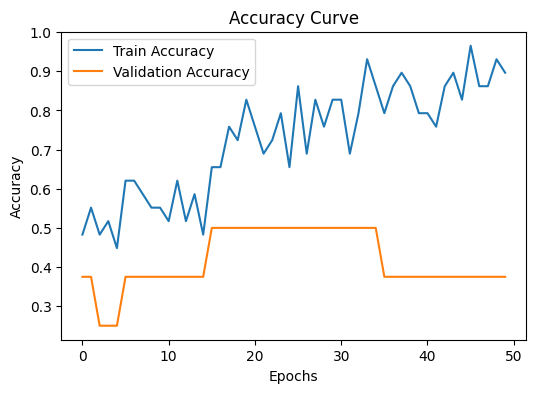

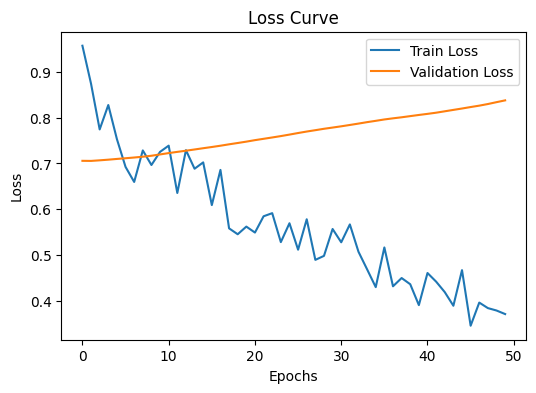

In [36]:
# STEP 5: Deep Learning Model (ANN)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("/content/agriculture_dataset_classification.csv")

# Encode target label if needed
# Check if 'Yield_Class' is of object type before encoding
if df['Yield_Class'].dtype == 'object':
    le = LabelEncoder()
    df['Yield_Class'] = le.fit_transform(df['Yield_Class'])

# Split into features and target
X = df.drop(['Farm_ID', 'Yield(tons)', 'Yield_Class'], axis=1) # Drop Farm_ID, original yield, and the target
y = df['Yield_Class']

# One-hot encode target for ANN
y_cat = to_categorical(y)

# Convert categorical features to numerical (One Hot Encoding)
X = pd.get_dummies(X, drop_first=True)


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.25, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN Model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_cat.shape[1], activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Performance Metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='macro')
recall = recall_score(y_test_classes, y_pred_classes, average='macro')
f1 = f1_score(y_test_classes, y_pred_classes, average='macro')

print("✅ ANN Model Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Plot Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.legend()
plt.show()